In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from vis import make_yref, load_border_vertices_xml
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
from sklearn.preprocessing import MinMaxScaler
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
from nilearn import surface
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd
import seaborn as sns
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

In [3]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'
experiment2 = 'smp0'

In [4]:
from vis import demographics
print('-----Experiment 1:')
_ = demographics(experiment)
print('-----Experiment 2:')
_ = demographics(experiment2)

-----Experiment 1:
Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64
-----Experiment 2:
Total Participants: 10
Gender Distribution: sex
M    8
F    2
Name: count, dtype: int64
Average Age: 25.7
SD Age: 3.7727090178455764
Age Range: (np.int64(21), np.int64(32))
Handedness Distribution: handedness
right    9
left     1
Name: count, dtype: int64


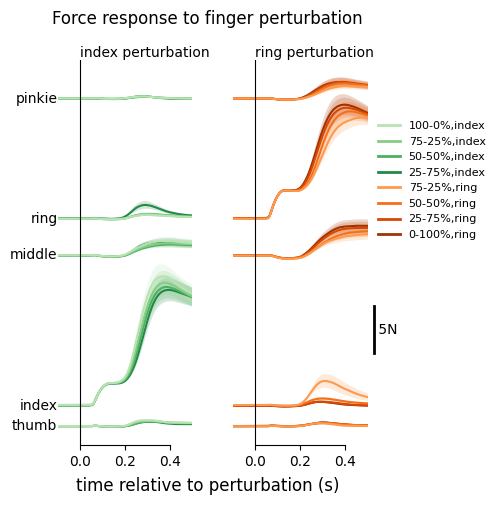

In [5]:
from vis import plot_force_aligned, add_sig_comp_bayes

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_force_aligned(fig, axs, force, descr)
plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 20.7316 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  7.4148 3.0000 39.0000 0.0005



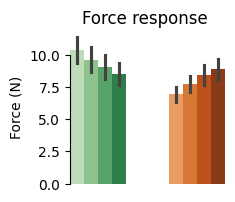

In [6]:
from vis import plot_force_binned

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_force_binned(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 10)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



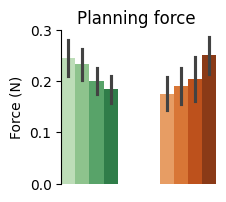

In [7]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .3)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

[]

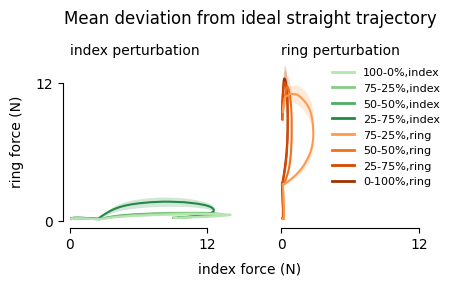

In [8]:
from vis import plot_dev_aligned

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
plot_dev_aligned(fig, axs, force, descr)

plt.plot()

rmANOVA index
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond 17.8907 1.0000 13.0000 0.0010

rmANOVA ring
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond  6.7472 1.0000 13.0000 0.0221



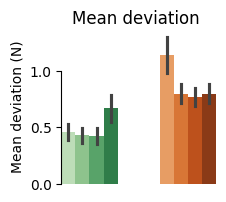

In [9]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 1)
axs[0].set_ylabel('Mean deviation (N)')
dat_stat = dat.copy()
dat_stat['correspond'] = 'high'
mask_low = ((dat_stat['cue'] == '75-25%') & (dat_stat['stimFinger'] == 'ring')) | ((dat_stat['cue'] == '25-75%') & (dat_stat['stimFinger'] == 'index'))
dat_stat.loc[mask_low, 'correspond'] = 'low'
dat_stat = dat_stat[dat_stat['GoNogo'] == 'go']

dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()

anova_index = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='index'], depvar='index1', subject='sn', within=['correspond'])
anova_ring = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['correspond'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

fig.suptitle('Mean deviation')

plt.show()

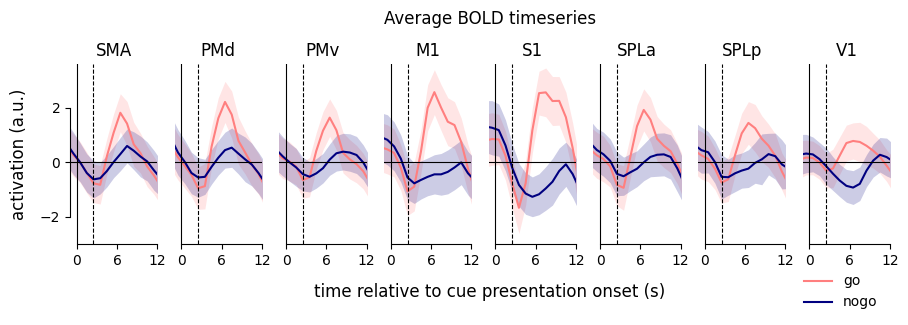

In [10]:
from vis import plot_bold

H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sns = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Ts = [os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in sns]
T = concat_hrf(Ts)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3))
fig, axs = plot_bold(fig, axs, T, H, rois)

plt.show()

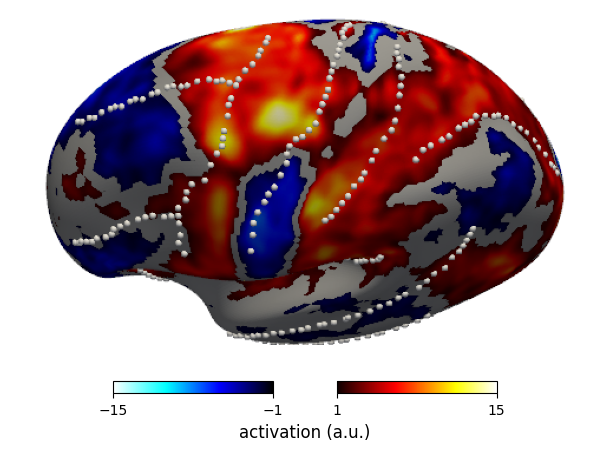

In [11]:
from vis import plot_surf

cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
H = 'L'
thresh = 1
vmin, vmax = -15, 15

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

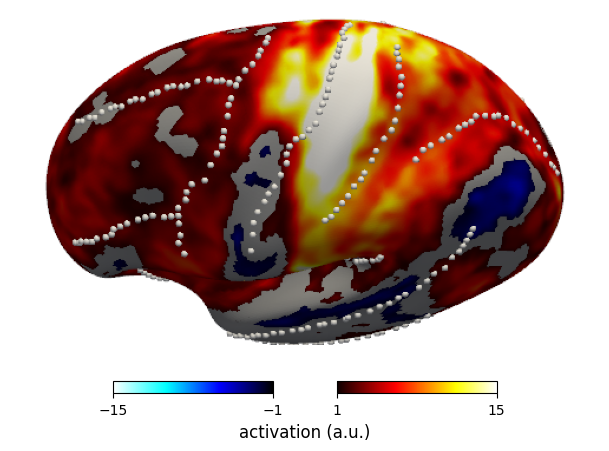

In [12]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, 'L', cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

ROI: SMA
planning vs. execution: tval=-0.3229932285250466, pval=0.7518367389243134
planning vs. 0: tval=3.0501993503244074, pval=0.00929641152551975
execution vs. 0: tval=2.8844843668975733, pval=0.012782937696076468
ROI: PMd
planning vs. execution: tval=-0.4780356934286871, pval=0.6405632164210409
planning vs. 0: tval=3.886242012611708, pval=0.0018743355566448975
execution vs. 0: tval=4.482046703653322, pval=0.0006172528156846847
ROI: PMv
planning vs. execution: tval=-0.6179286255988247, pval=0.5472955590172652
planning vs. 0: tval=3.5352843332538777, pval=0.003658089075464079
execution vs. 0: tval=2.7611488387710907, pval=0.016189211246084075
ROI: M1
planning vs. execution: tval=1.796478084065509, pval=0.09568112110267324
planning vs. 0: tval=2.8121366650325212, pval=0.014684526345514723
execution vs. 0: tval=6.848729354222539, pval=1.1725664423993211e-05
ROI: S1
planning vs. execution: tval=4.608984772840678, pval=0.0004896361254904716
planning vs. 0: tval=0.7258302279090869, pval=0

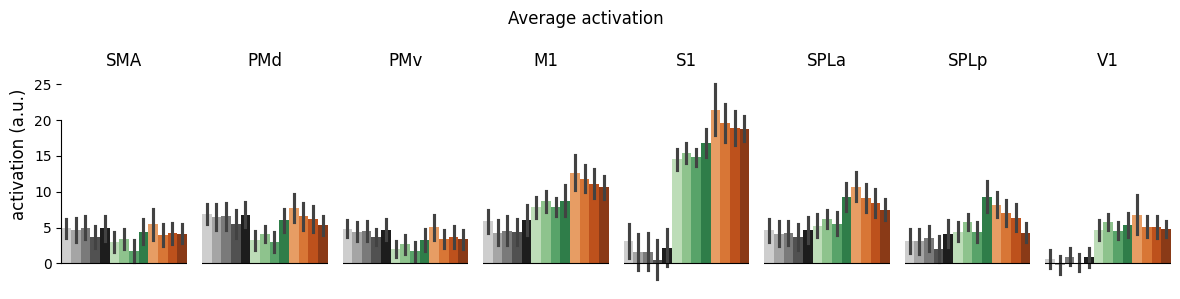

In [13]:
from vis import plot_avg_activation

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
axs[0].spines[['left', ]].set_bounds(0, 20)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    tval, pval = ttest_rel(exec, plan)
    print(f'planning vs. execution: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(plan, 0)
    print(f'planning vs. 0: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(exec, 0)
    print(f'execution vs. 0: tval={tval}, pval={pval}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()

SMA: tval=3.8023070018726037, pval=0.002197683358041902
PMd: tval=5.338327170498892, pval=0.0001346706868366469
PMv: tval=5.219774695666767, pval=0.00016530878507726104
M1: tval=4.942572151530261, pval=0.00026895798058729914
S1: tval=6.781705376689908, pval=1.2980916784839038e-05
SPLa: tval=4.529690342136649, pval=0.0005657316059349151
SPLp: tval=6.2568270831551, pval=2.939612428894749e-05
V1: tval=4.563288150993307, pval=0.0005320933869378602


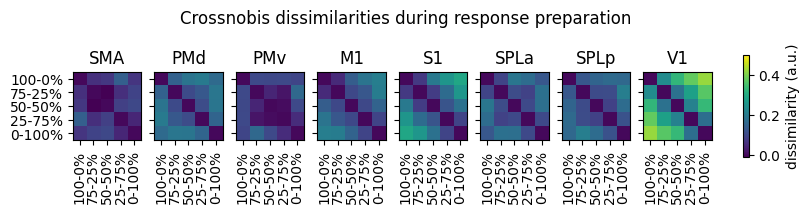

In [14]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

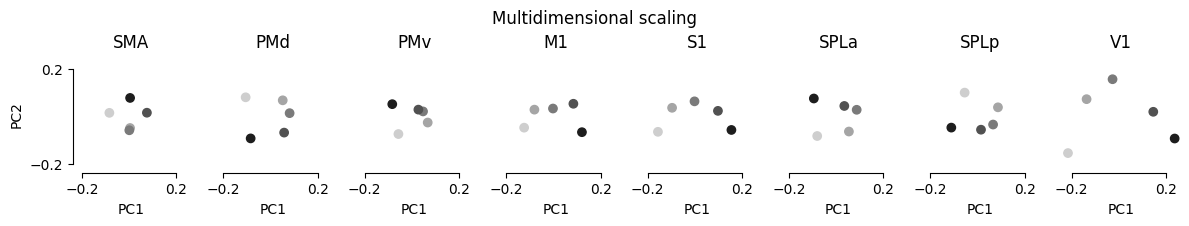

In [15]:
fig, axs = plt.subplots(1, len(rois), figsize=(12, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    ax=axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    mds, _ = pcm.classical_mds(G.mean(axis=0))
    ax.scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[:5])
    ax.set_aspect('equal')
    ax.set_ylim(ax.get_xlim())
    ax.set_xlabel('PC1')
    ax.set_title(roi)
    ax.set_xticks([-.2, .2])
    ax.set_yticks(ax.get_xticks())
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_bounds(-.2, .2)
    if r==0:
        ax.spines['left'].set_visible(True)
        ax.set_ylabel('PC2')
    else:
        ax.tick_params(axis='y', left=False)

fig.suptitle('Multidimensional scaling')
fig.tight_layout()

plt.show()

SMA: 0.743632971996515 upper noise
PMd: 0.9404393935326423 upper noise
PMv: 0.8775241724273561 upper noise
M1: 0.950474797248008 upper noise
S1: 0.9720379473994675 upper noise
SPLa: 0.8585651886897832 upper noise
SPLp: 0.8991163834402415 upper noise
V1: 0.920720859477944 upper noise
SMA, tval=2.5190493656008206, pval=0.01282500615302458
PMd, tval=2.593395477930472, pval=0.01114171490850471
PMv, tval=2.86501493546047, pval=0.006634692304026267
M1, tval=2.472908874242006, pval=0.01399054939759915
S1, tval=3.7677557651343117, pval=0.0011734232192166247
SPLa, tval=1.938542100411683, pval=0.03728961151800784
SPLp, tval=3.7575602493173497, pval=0.0011964030608804582
V1, tval=3.8090117549550757, pval=0.0010849388876064884


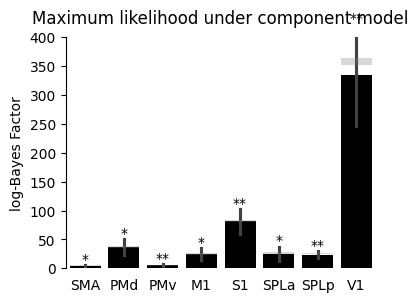

In [16]:
from vis import plot_likelihood

LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 400)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
cue, tval=1.3401867978746813, pval=0.10156932650201513
uncertainty, tval=1.5254217657313434, pval=0.07555415375587657
cue vs. uncertainty, tval=-0.3110935485386377, pval=0.7606617211274478

PMd:
cue, tval=3.8382608492543158, pval=0.0010263582910072142
uncertainty, tval=3.4652527610844714, pval=0.0020919141994411123
cue vs. uncertainty, tval=-0.8035086080462943, pval=0.43612699683976086

PMv:
cue, tval=1.7472753822389175, pval=0.05207698717900118
uncertainty, tval=2.03325585927743, pval=0.03148366034843932
cue vs. uncertainty, tval=-0.9712278260126664, pval=0.34915965870466514

M1:
cue, tval=3.4459588942817083, pval=0.002170835007031486
uncertainty, tval=1.459919001348959, pval=0.08402666559926511
cue vs. uncertainty, tval=2.9753157893122273, pval=0.010736552583686785

S1:
cue, tval=7.510688291010775, pval=2.2158172424707916e-06
uncertainty, tval=2.2088436024316924, pval=0.02287402918504579
cue vs. uncertainty, tval=4.020275305141971, pval=0.001455467330882188

SPLa:
cue, tval=3.0

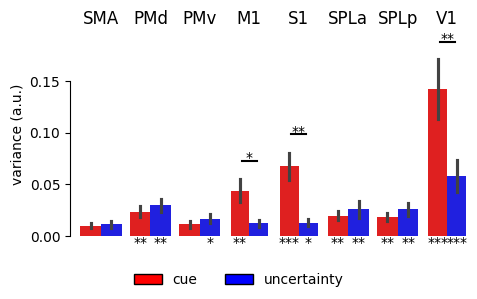

In [17]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.p'), 'component')
n_param_c = Mc.n_param
components = ['cue', 'uncertainty']
palette = ['red', 'blue']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = plot_var_expl(fig, axs, r, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

M1-S1/prem-pariet ratio, tval=4.846673169382468, pval=0.00031904213826427195


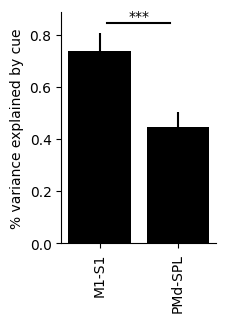

In [18]:
rois_prim = ['M1', 'S1']
rois_high = ['PMd', 'SPLa', 'SPLp']

var_expl_prim = []
for roi in rois_prim:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_prim.append(np.exp(param_c))

var_expl_high = []
for roi in rois_high:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_high.append(np.exp(param_c))

var_expl_prim = np.array(var_expl_prim).mean(axis=0)
var_expl_high = np.array(var_expl_high).mean(axis=0)
ratio_prim = var_expl_prim[0] / (var_expl_prim[1] + var_expl_prim[0])
ratio_high = var_expl_high[0] / (var_expl_high[1] + var_expl_high[0])
ratio = np.c_[ratio_prim, ratio_high]
ratio_avg = ratio.mean(axis=0)
ratio_err = ratio.std(axis=0) / np.sqrt(ratio.shape[0])

fig, ax = plt.subplots(figsize=(2, 3))

ax.bar(['M1-S1', 'PMd-SPL'], ratio_avg, yerr=ratio_err, facecolor='k')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticklabels(labels=['M1-S1', 'PMd-SPL'], rotation=90)
ax.set_ylabel('% variance explained by cue')

tval, pval = ttest_rel(ratio[:, 0], ratio[:, 1], alternative='two-sided')
print(f"M1-S1/prem-pariet ratio, tval={tval}, pval={pval}")
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = None
if stars:
    y_max = ratio.mean(axis=0).max()
    y_argmax = ratio.mean(axis=0).argmax()
    se = ratio[y_argmax].std() / np.sqrt(ratio.shape[0])
    y_max += se
    y_max0 = y_max
    center = .5
    x1 = center - .4
    x2 = center + .4
    offset = .1 * ax.get_ylim()[1]
    ax.plot([x1, x2], [y_max + offset , y_max + offset], lw=1.5, c='k')
    ax.text(center, y_max + offset, stars, ha='center', va='bottom', fontsize=10)

plt.show()

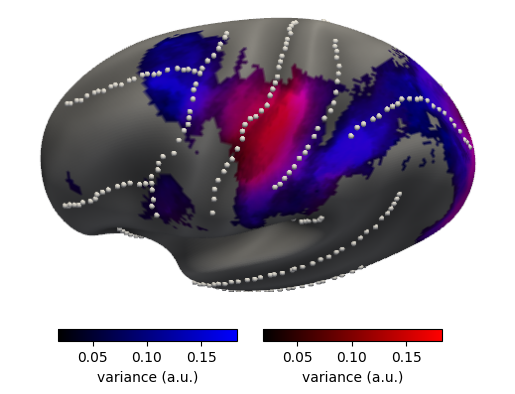

In [19]:
mclip = .3
threshold = .1 / mclip
scaler = MinMaxScaler()

gifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
raw_max = np.nanmax(data)
data = scaler.fit_transform(data)
raw_min = scaler.inverse_transform([[threshold * mclip, threshold * mclip]])[0,0]
data = np.clip(data / mclip, 0, 1)

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

blue_half = LinearSegmentedColormap.from_list("blue_half", ["black", "blue"])
neg_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", ["black", "red"])
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('variance (a.u.)')
cbar_pos.set_label('variance (a.u.)')

plt.show()

Likelihood of cue model
tval=2.4601259124512476, pval=0.014331091593496511
0.93 noise ceiling
force: tval=3.2106057951069467, pval=0.006826772009600081


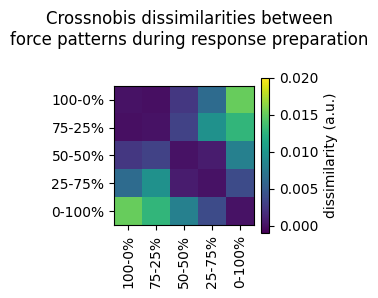

In [20]:
fig, ax = plt.subplots(figsize=(2, 3))

vmin, vmax = -.001, .02

T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.force.plan.p'))

bf_cue = T_cv.likelihood['cue'] - T_cv.likelihood['null']
bf_noise = T_cv.likelihood['ceil'] - T_cv.likelihood['null']

tval, pval = ttest_1samp(bf_cue, 0, alternative='greater')
print(f'Likelihood of cue model\ntval={tval}, pval={pval}')
print(f'{bf_cue.mean() / bf_noise.mean():.02f} noise ceiling')

G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.force.plan.npy'))
D = pcm.G_to_dist(G)
fig, ax = plot_dissimilarities(fig, ax, None, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarities between\nforce patterns during response preparation')

plt.show()


M1
slope: -0.12347189193429275, p = 0.310
intercept: 0.030693358679978668, p_intercept = 0.001
R2 = 0.086

S1
slope: -0.002123651207652234, p = 0.986
intercept: 0.034002320000430505, p_intercept = 0.001
R2 = 0.000


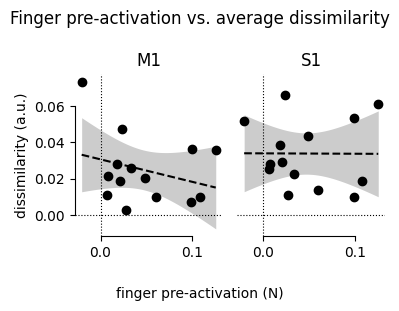

In [21]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']
diff = np.zeros(len(sns))
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
for s, sn in enumerate(sns):
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    dat = dat[(dat['cue']==93) | (dat['cue']==39)]
    diff[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    x = diff
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('finger pre-activation (N)', fontsize=10)

fig.suptitle('Finger pre-activation vs. average dissimilarity')

fig.tight_layout()

plt.show()

SMA: tval=4.175576485162719, pval=0.0010880001325376414
PMd: tval=5.753408040291076, pval=6.671781340250782e-05
PMv: tval=4.673197472344499, pval=0.0004358264937615878
M1: tval=4.833842307590951, pval=0.00032644519592054945
S1: tval=4.135884646980293, pval=0.0011717360207945322
SPLa: tval=4.726749911420754, pval=0.00039565621707251804
SPLp: tval=5.318396421312414, pval=0.00013937367685868245
V1: tval=6.0944545729027695, pval=3.814397497826191e-05


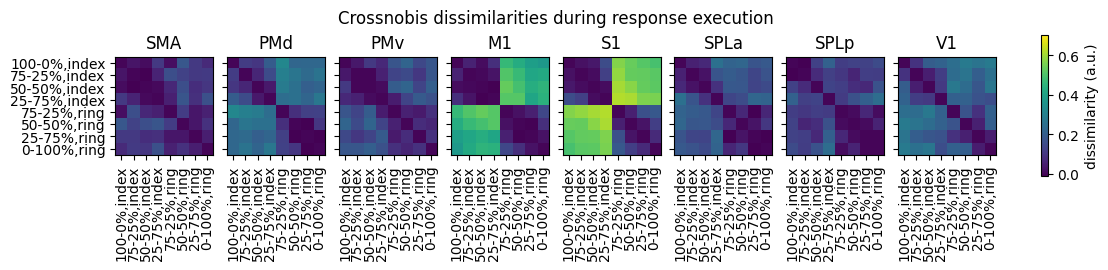

In [22]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

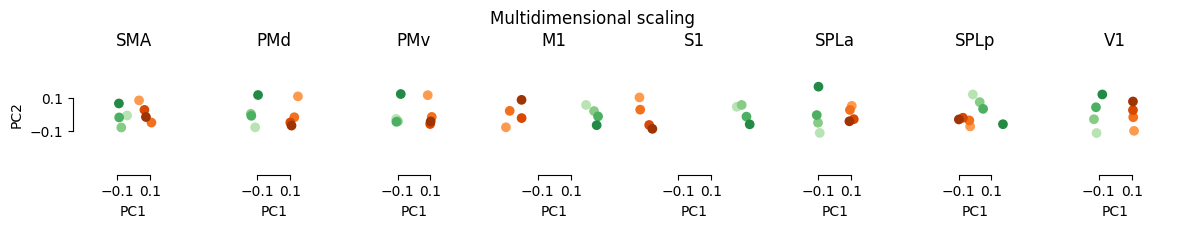

In [23]:
fig, axs = plt.subplots(1, len(rois), figsize=(12, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    ax=axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    mds, _ = pcm.classical_mds(G.mean(axis=0))
    ax.scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[5:13])
    ax.set_aspect('equal')
    ax.set_ylim(ax.get_xlim())
    ax.set_xlabel('PC1')
    ax.set_title(roi)
    ax.set_xticks([-.1, .1])
    ax.set_yticks(ax.get_xticks())
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_bounds(-.1, .1)
    if r==0:
        ax.spines['left'].set_visible(True)
        ax.set_ylabel('PC2')
    else:
        ax.tick_params(axis='y', left=False)

fig.suptitle('Multidimensional scaling')
fig.tight_layout()

plt.show()

SMA: 0.08225221539687541 upper noise
PMd: 0.11410278300016341 upper noise
PMv: 0.14171748788117738 upper noise
M1: 0.5812732320658893 upper noise
S1: 0.6874812960443734 upper noise
SPLa: 0.12310949332910007 upper noise
SPLp: 0.12138473060622736 upper noise
V1: 0.038802613553234125 upper noise
SMA, tval=3.3248430690406954, pval=0.002739747237196585
PMd, tval=6.957844359095228, pval=4.974562425821801e-06
PMv, tval=4.325893191006019, pval=0.0004114316264940157
M1, tval=3.8783564058700133, pval=0.0009512629060906403
S1, tval=4.139291119669088, pval=0.0005821481399474142
SPLa, tval=4.539620512761532, pval=0.0002777830535124662
SPLp, tval=2.543677588966856, pval=0.012241826231225137
V1, tval=2.3283539749378726, pval=0.018337502273384768


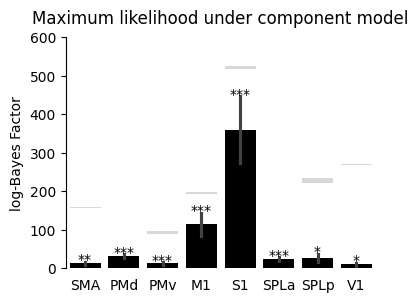

In [24]:
LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 600)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
finger, tval=-0.12954953537468214, pval=0.5505470857289387
cue, tval=-4472.243575089086, pval=1.0
surprise, tval=4.183020151288472, pval=0.0005364976846302934
finger vs. cue, tval=2.2851019741553293, pval=0.03974160504780439
finger vs. surprise, tval=-4.467573804216429, pval=0.0006338474782097602
cue vs. surprise, tval=-8.034826392705247, pval=2.1322378173025724e-06

PMd:
finger, tval=3.993188617942421, pval=0.000765800326003115
cue, tval=-2.6336790683393354, pval=0.9896787199638006
surprise, tval=7.540735660613348, pval=2.1228854704188197e-06
finger vs. cue, tval=4.19649687284879, pval=0.00104636897479796
finger vs. surprise, tval=-1.353185308768246, pval=0.1990603499553831
cue vs. surprise, tval=-7.383290120267994, pval=5.321096775152345e-06

PMv:
finger, tval=1.465843886133755, pval=0.08322873526220717
cue, tval=-2041.1065841773066, pval=1.0
surprise, tval=3.937847438044441, pval=0.0008500507963470267
finger vs. cue, tval=1.9419898766663155, pval=0.07412425463172087
finger vs.

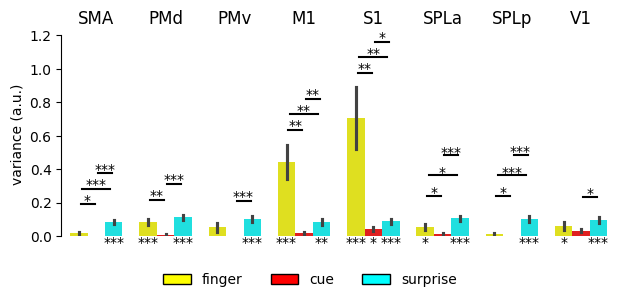

In [25]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
palette = ['#FFFF00', 'red', 'cyan']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(7, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = plot_var_expl(fig, axs, r, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

M1-S1/prem-pariet ratio, tval=17.602497206930124, pval=1.8901090463594675e-10


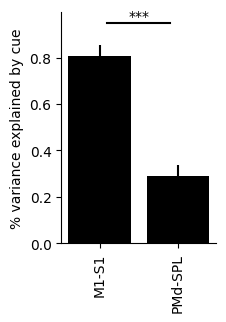

In [26]:
rois_prim = ['M1', 'S1']
rois_high = ['PMd', 'SPLa', 'SPLp']

var_expl_prim = []
for roi in rois_prim:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_prim.append(np.exp(param_c))

var_expl_high = []
for roi in rois_high:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_high.append(np.exp(param_c))

var_expl_prim = np.array(var_expl_prim).mean(axis=0)
var_expl_high = np.array(var_expl_high).mean(axis=0)
ratio_prim = var_expl_prim[0] / (var_expl_prim[-1] + var_expl_prim[0])
ratio_high = var_expl_high[0] / (var_expl_high[-1] + var_expl_high[0])
ratio = np.c_[ratio_prim, ratio_high]
ratio_avg = ratio.mean(axis=0)
ratio_err = ratio.std(axis=0) / np.sqrt(ratio.shape[0])

fig, ax = plt.subplots(figsize=(2, 3))

ax.bar(['M1-S1', 'PMd-SPL'], ratio_avg, yerr=ratio_err, facecolor='k')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticklabels(labels=['M1-S1', 'PMd-SPL'], rotation=90)
ax.set_ylabel('% variance explained by cue')

tval, pval = ttest_rel(ratio[:, 0], ratio[:, 1], alternative='two-sided')
print(f"M1-S1/prem-pariet ratio, tval={tval}, pval={pval}")
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = None
if stars:
    y_max = ratio.mean(axis=0).max()
    y_argmax = ratio.mean(axis=0).argmax()
    se = ratio[y_argmax].std() / np.sqrt(ratio.shape[0])
    y_max += se
    y_max0 = y_max
    center = .5
    x1 = center - .4
    x2 = center + .4
    offset = .1 * ax.get_ylim()[1]
    ax.plot([x1, x2], [y_max + offset , y_max + offset], lw=1.5, c='k')
    ax.text(center, y_max + offset, stars, ha='center', va='bottom', fontsize=10)

plt.show()

SMA: correlation=-0.9999992755383944+/-2.884469272998132e-07
PMd: correlation=-0.9999989578942706+/-3.5592584640247433e-07
PMv: correlation=-0.9999971271580032+/-1.0751238275828173e-06
M1: correlation=-0.9194552059981689+/-0.023104074645668413
S1: correlation=-0.8332588342989141+/-0.034978168219991314
SPLa: correlation=-0.9856136209289738+/-0.01386264443728042
SPLp: correlation=-0.9999994155356501+/-3.071372863517192e-07
V1: correlation=-0.9774089665212607+/-0.015362601679864118
SMA, tval=-3340730.381742515, pval=5.852184237888605e-79
PMd, tval=-2707370.417745883, pval=8.997807696250421e-78
PMv, tval=-896288.7051681366, pval=1.568315847354399e-71
M1, tval=-38.34861251440492, pval=9.232558586642523e-15
S1, tval=-22.955699078739926, pval=6.629256866578964e-12
SPLa, tval=-68.51225638832317, pval=5.069697835343053e-18
SPLp, tval=-3137435.900087999, pval=1.323681002529377e-78
V1, tval=-61.308290530406026, pval=2.1399809608660838e-17


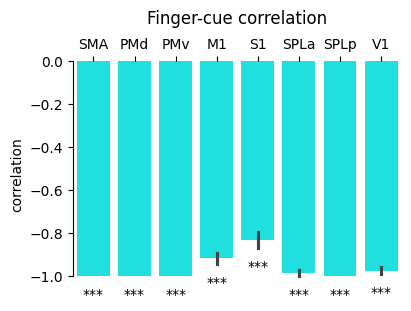

In [27]:
from vis import plot_interaction, add_sig_to_bars

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.exec.p'), 'feature')
n_param_f = Mf.n_param
interaction = {'roi': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
for roi in rois:
    f = open(os.path.join(pcm_path, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    theta = param[idxf][:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    print(f'{roi}: correlation={correlation.mean()}+/-{correlation.std() / np.sqrt(correlation.size)}')
    interaction['roi'].extend([roi] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction)
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='roi')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-1])
ax.set_title('Finger-cue correlation', pad=10)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()


SMA
slope: -0.0030083348834384523, p = 0.450
intercept: 0.08762097168644453, p_intercept = 0.003
R2 = 0.001

PMd
slope: -0.01860174934819801, p = 0.272
intercept: 0.12787801410370242, p_intercept = 0.001
R2 = 0.032

PMv
slope: -0.008172440622798734, p = 0.416
intercept: 0.1094198502823665, p_intercept = 0.014
R2 = 0.004

M1
slope: -0.030663872952165504, p = 0.228
intercept: 0.10912282910062963, p_intercept = 0.019
R2 = 0.047

S1
slope: -0.023241208343853497, p = 0.224
intercept: 0.10854764379633036, p_intercept = 0.004
R2 = 0.049

SPLa
slope: 0.008382298824669593, p = 0.608
intercept: 0.09710957984973101, p_intercept = 0.008
R2 = 0.007

SPLp
slope: -0.00930582582219066, p = 0.403
intercept: 0.11114118401542408, p_intercept = 0.012
R2 = 0.005

V1
slope: 0.009245465037977853, p = 0.591
intercept: 0.08597982351721051, p_intercept = 0.053
R2 = 0.005


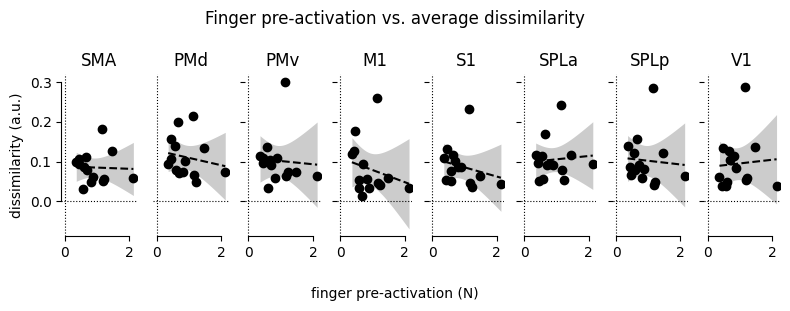

In [28]:
from vis import plot_correlation

pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
behav = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'smp2_force_single_trial.tsv'), sep='\t')
behav = behav.groupby(['sn', 'stimFinger', 'cue', 'GoNogo']).mean(numeric_only=True).reset_index()
behav = behav[((behav.stimFinger=='index') & (behav.cue=='25-75%')) | ((behav.stimFinger=='ring') & (behav.cue=='75-25%'))]
behav = behav.groupby('sn').mean(numeric_only=True).reset_index()
x = behav.MD

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3))

for r, roi in enumerate(rois):
    print(f'\n{roi}')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl = np.exp(param_c)
    # theta = param[idxf][:n_param_f]
    # theta2 = theta ** 2
    # covariance = theta[1] * theta[2]
    # stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    # correlation = covariance / stds
    y = var_expl[2]
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='less', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('finger pre-activation (N)', fontsize=10)

fig.suptitle('Finger pre-activation vs. average dissimilarity')

fig.tight_layout()

plt.show()

group estimate:0.16166860564112248 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.34065963421359396 central 90% CI for r: [-0.530, -0.188]
group estimate:-0.9999999878670197 central 90% CI for r: [-1.000, -0.598]
group estimate:0.6377649766746591 central 90% CI for r: [0.542, 0.708]
group estimate:0.6260546784849649 central 90% CI for r: [0.519, 0.719]
group estimate:-0.7419335144518395 central 90% CI for r: [-0.987, -0.579]
group estimate:-1.0 central 90% CI for r: [-1.000, -0.703]
group estimate:0.3497705657534667 central 90% CI for r: [0.197, 0.467]


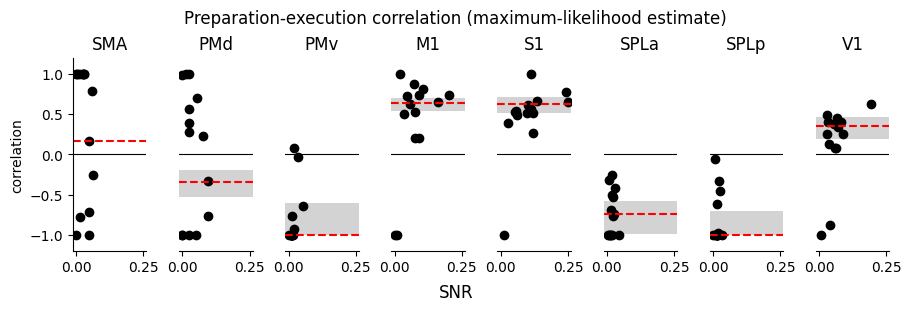

In [29]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_plan-exec.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_plan-exec.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_plan-exec.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Preparation-execution correlation (maximum-likelihood estimate)')

plt.show()


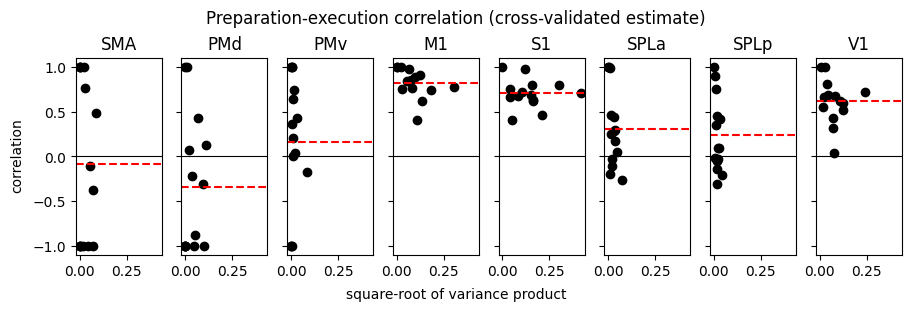

In [35]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_plan-exec.glm{glm}.{H}.{roi}.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2), -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(roi)

fig.suptitle('Preparation-execution correlation (cross-validated estimate)')
fig.supxlabel('square-root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()

group estimate:-0.9999999979616829 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999988900758 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999998246 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.6199426947430792 central 90% CI for r: [-0.715, -0.555]
group estimate:-0.6538670575182669 central 90% CI for r: [-0.788, -0.523]
group estimate:-0.9999999990639142 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999998774335 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999177495 central 90% CI for r: [-1.000, -1.000]


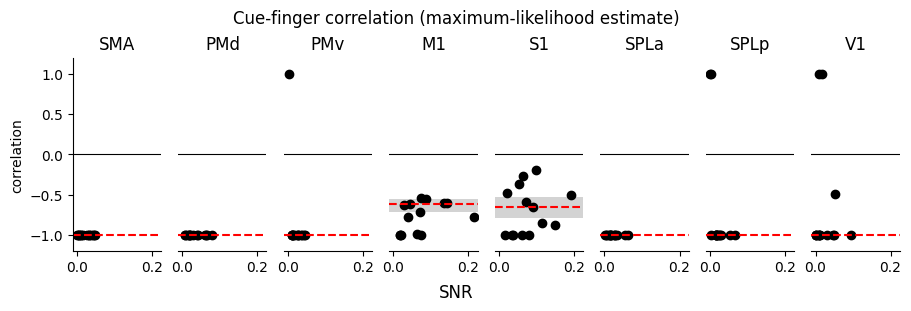

In [48]:
fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_cue-finger.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_cue-finger.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_cue-finger.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-finger correlation (maximum-likelihood estimate)')

plt.show()


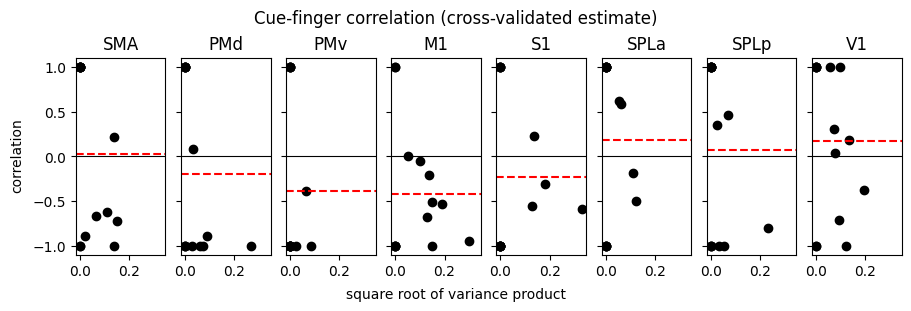

In [49]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_cue-finger.glm{glm}.{H}.{roi}.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2), -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(roi)

fig.suptitle('Cue-finger correlation (cross-validated estimate)')
fig.supxlabel('square root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()